# Derivación del Método de Elementos Finitos para la Ecuación de Helmholtz 1D

Este documento detalla la derivación matemática y la implementación computacional del Método de Elementos Finitos (MEF) para la ecuación de Helmholtz en 1D, utilizando elementos continuos y lineales a trozos, e incorporando condiciones de frontera de tipo Robin.

---

## 1. Planteamiento del Problema (Formulación Fuerte)

Consideremos el dominio espacial $\Omega = (-1, 1)$. Buscamos una función compleja $u(x): \Omega \rightarrow \mathbb{C}$ que satisfaga la ecuación de Helmholtz:

$$
-\frac{d^2 u}{dx^2} - k^2 u = f(x) \quad \text{para } x \in (-1, 1)
$$

donde:
* $k \in \mathbb{R}$ es el número de onda.
* $f(x)$ es una función fuente dada.

### Condiciones de Frontera de Robin
Imponemos las siguientes condiciones en los extremos del dominio:
* En $x = -1$: $\quad -u'(-1) + \sigma_1 u(-1) = g_1$
* En $x = 1$:  $\quad u'(1) + \sigma_2 u(1) = g_2$

Donde $\sigma_1, \sigma_2, g_1, g_2$ son constantes (o parámetros complejos) dados.

---

## 2. Formulación Variacional (Débil)

Dado que la solución $u(x)$ puede ser compleja, multiplicamos la ecuación diferencial por el **conjugado complejo** de una función de prueba arbitraria $v(x)$, denotada como $\bar{v}$, e integramos sobre todo el dominio:

$$
\int_{-1}^{1} \left( -u'' - k^2 u \right) \bar{v} \, dx = \int_{-1}^{1} f \bar{v} \, dx
$$

Aplicamos integración por partes al primer término (término de difusión):

$$
\int_{-1}^{1} -u'' \bar{v} \, dx = \int_{-1}^{1} u' \bar{v}' \, dx - \left[ u' \bar{v} \right]_{-1}^{1}
$$

Sustituyendo esto en la ecuación integral obtenemos:

$$
\int_{-1}^{1} u' \bar{v}' \, dx - \left( u'(1)\bar{v}(1) - u'(-1)\bar{v}(-1) \right) - k^2 \int_{-1}^{1} u \bar{v} \, dx = \int_{-1}^{1} f \bar{v} \, dx
$$

Ahora, sustituimos los términos de la frontera usando nuestras condiciones de Robin:
* $u'(1) = g_2 - \sigma_2 u(1)$
* $u'(-1) = \sigma_1 u(-1) - g_1$

Lo que nos da:

$$
-\left[ u'\bar{v} \right]_{-1}^1 = -(g_2 - \sigma_2 u(1))\bar{v}(1) + (\sigma_1 u(-1) - g_1)\bar{v}(-1)
$$

Reorganizando los términos para dejar las incógnitas ($u$) a la izquierda y los datos conocidos a la derecha, llegamos a la **Formulación Débil**:

$$
\int_{-1}^{1} \left( u' \bar{v}' - k^2 u \bar{v} \right) dx + \sigma_2 u(1)\bar{v}(1) + \sigma_1 u(-1)\bar{v}(-1) = \int_{-1}^{1} f \bar{v} \, dx + g_2 \bar{v}(1) + g_1 \bar{v}(-1)
$$

**Nota Importante:** Como se discutió previamente, aunque escribimos $\bar{v}$ por rigor matemático para espacios complejos, en el momento de la discretización utilizaremos funciones de base estrictamente reales, por lo que $\bar{v}(x) = v(x)$.

---

## 3. Discretización (Espacio de Elementos Lineales a Trozos)

Dividimos el dominio $[-1, 1]$ en $N$ elementos usando $N+1$ nodos:
$$-1 = x_0 < x_1 < x_2 < \dots < x_N = 1$$

Definimos el espacio de aproximación de dimensión finita $V_h$ generado por funciones de base polinómicas lineales a trozos (funciones "sombrero" o *hat functions*) $\phi_j(x)$ para $j = 0, \dots, N$. 

Dado que $\phi_j(x)$ son **reales**, $\bar{\phi}_j(x) = \phi_j(x)$.

Aproximamos la solución como:
$$u_h(x) = \sum_{j=0}^{N} U_j \phi_j(x)$$
donde $U_j$ son los coeficientes nodales (que serán complejos). Elegimos las funciones de prueba $v = \phi_i(x)$ para $i = 0, \dots, N$.

Sustituyendo $u_h$ y $v$ en la formulación débil, obtenemos el sistema de ecuaciones algebraico:
$$\sum_{j=0}^{N} U_j \left[ \int_{-1}^{1} (\phi_j' \phi_i' - k^2 \phi_j \phi_i) \, dx + \sigma_2 \phi_j(1)\phi_i(1) + \sigma_1 \phi_j(-1)\phi_i(-1) \right] = \int_{-1}^{1} f \phi_i \, dx + g_2 \phi_i(1) + g_1 \phi_i(-1)$$

En forma matricial:
$$\mathbf{K} \mathbf{U} = \mathbf{F}$$

---

## 4. Ensamblaje de Matrices Locales a Globales

Para construir $\mathbf{K}$ y $\mathbf{F}$, evaluamos las integrales elemento por elemento. 
Sea un elemento $e$ definido por los nodos $[x_a, x_b]$ con longitud $h = x_b - x_a$. Las funciones de base locales son:
$$\phi_1^{(e)}(x) = \frac{x_b - x}{h}, \quad \phi_2^{(e)}(x) = \frac{x - x_a}{h}$$

### Matriz de Rigidez Local (Derivadas)
$$\mathbf{K}_{stiff}^{(e)} = \int_{x_a}^{x_b} \nabla\phi^{(e)} \cdot (\nabla\phi^{(e)})^T \, dx = \frac{1}{h} \begin{pmatrix} 1 & -1 \\ -1 & 1 \end{pmatrix}$$

### Matriz de Masa Local (Términos sin derivadas)
$$\mathbf{M}_{mass}^{(e)} = \int_{x_a}^{x_b} \phi^{(e)} (\phi^{(e)})^T \, dx = \frac{h}{6} \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$$

### Matriz Local Completa del Elemento
$$\mathbf{K}^{(e)} = \mathbf{K}_{stiff}^{(e)} - k^2 \mathbf{M}_{mass}^{(e)}$$
$$\mathbf{K}^{(e)} = \frac{1}{h} \begin{pmatrix} 1 & -1 \\ -1 & 1 \end{pmatrix} - k^2 \frac{h}{6} \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$$

### Vector de Carga Local
Asumiendo que $f(x)$ es constante o aproximada por su promedio en el elemento $f_e$:
$$\mathbf{F}^{(e)} = \int_{x_a}^{x_b} f_e \phi^{(e)} \, dx = \frac{f_e h}{2} \begin{pmatrix} 1 \\ 1 \end{pmatrix}$$

### Condiciones de Frontera Robin (Ensamblaje Global)
Una vez ensamblada la matriz global $\mathbf{K}$ y el vector $\mathbf{F}$ sumando las contribuciones locales, agregamos los términos de contorno:
* **En $x = -1$ (Nodo 0):** $\quad K_{0,0} \leftarrow K_{0,0} + \sigma_1, \quad F_0 \leftarrow F_0 + g_1$
* **En $x = 1$ (Nodo N):** $\quad K_{N,N} \leftarrow K_{N,N} + \sigma_2, \quad F_N \leftarrow F_N + g_2$

---

## 5. Implementación en Python (NumPy / SciPy)

A continuación, un esquema del código Python utilizando aritmética compleja nativa (`dtype=complex`).






--- Tabla de Convergencia ---
  N          h   Error L2   Orden L2  Error Linf  Orden Linf
 10 2.0000e-01 6.3997e-02        NaN  7.8361e-02         NaN
 20 1.0000e-01 1.5481e-02 2.0475e+00  1.9879e-02  1.9789e+00
 40 5.0000e-02 3.7919e-03 2.0295e+00  4.9880e-03  1.9947e+00
 80 2.5000e-02 9.3738e-04 2.0162e+00  1.2481e-03  1.9987e+00
160 1.2500e-02 2.3297e-04 2.0085e+00  3.1211e-04  1.9997e+00
320 6.2500e-03 5.8070e-05 2.0043e+00  7.8031e-05  1.9999e+00
640 3.1250e-03 1.4495e-05 2.0022e+00  1.9508e-05  2.0000e+00


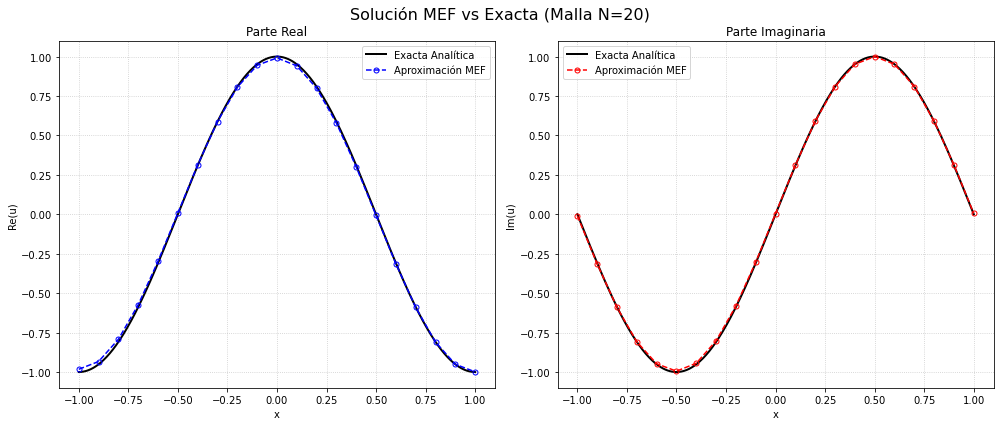

In [12]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Función del Método de Elementos Finitos
# ---------------------------------------------------------
def resolve_helmholtz_1d(N, k, f_func, sigma1, sigma2, g1, g2):
    x = np.linspace(-1.0, 1.0, N+1)
    h = x[1] - x[0]

    K = np.zeros((N+1, N+1), dtype=complex)
    F = np.zeros(N+1, dtype=complex)

    K_stiff_loc = (1.0/h) * np.array([[1, -1], [-1, 1]], dtype=complex)
    M_mass_loc  = (h/6.0) * np.array([[2, 1], [1, 2]], dtype=complex)
    K_loc = K_stiff_loc - (k**2) * M_mass_loc

    for e in range(N):
        n1, n2 = e, e+1
        K[n1:n2+1, n1:n2+1] += K_loc

        # Integral de f(x) por regla del punto medio
        x_mid = 0.5 * (x[n1] + x[n2])
        F_loc = (f_func(x_mid) * h / 2.0) * np.array([1, 1], dtype=complex)
        
        F[n1] += F_loc[0]
        F[n2] += F_loc[1]

    # Condiciones de frontera de Robin
    K[0, 0] += sigma1
    F[0] += g1
    K[N, N] += sigma2
    F[N] += g2

    K_sparse = sp.csr_matrix(K)
    U = spla.spsolve(K_sparse, F)

    return x, U

# ---------------------------------------------------------
# 2. Configuración de la Solución Manufacturada (MMS)
# ---------------------------------------------------------
k = 2.0
sigma1 = 1.0j
sigma2 = 1.0j

# Solución exacta: u(x) = exp(i * pi * x)
def u_exacta(x):
    return np.exp(1j * np.pi * x)

# Función fuente f(x) obtenida analíticamente
def fuente_f(x):
    return (np.pi**2 - k**2) * np.exp(1j * np.pi * x)

# Condiciones de frontera exactas
g1 = 1j * (np.pi - 1.0)
g2 = -1j * (np.pi + 1.0)

# ---------------------------------------------------------
# 3. Test de Convergencia guardado en un DataFrame
# ---------------------------------------------------------
N_values = [10, 20, 40, 80, 160, 320, 640]
resultados = []

# Variables para guardar una solución específica para graficar
N_plot = 20  # Usaremos N=40 para que los nodos numéricos sean visibles en la gráfica
x_plot, u_num_plot, u_ex_plot = None, None, None

for i, N in enumerate(N_values):
    x_num, u_num = resolve_helmholtz_1d(N, k, fuente_f, sigma1, sigma2, g1, g2)
    h = x_num[1] - x_num[0]
    u_ex = u_exacta(x_num)
    
    error_L2 = np.sqrt(np.sum(np.abs(u_num - u_ex)**2) * h)
    error_Linf = np.max(np.abs(u_num - u_ex))
    
    orden_L2 = np.nan
    orden_Linf = np.nan
    
    if i > 0:
        h_prev = resultados[-1]['h']
        eL2_prev = resultados[-1]['Error L2']
        eLinf_prev = resultados[-1]['Error Linf']
        
        orden_L2 = np.log(eL2_prev / error_L2) / np.log(h_prev / h)
        orden_Linf = np.log(eLinf_prev / error_Linf) / np.log(h_prev / h)
        
    resultados.append({
        'N': N,
        'h': h,
        'Error L2': error_L2,
        'Orden L2': orden_L2,
        'Error Linf': error_Linf,
        'Orden Linf': orden_Linf
    })
    
    # Guardamos los datos de la malla seleccionada para la gráfica
    if N == N_plot:
        x_plot = x_num
        u_num_plot = u_num
        # Generamos una malla mucho más fina para dibujar la curva exacta suavemente
        x_fino = np.linspace(-1.0, 1.0, 500)
        u_ex_plot = u_exacta(x_fino)
        x_ex_plot = x_fino

# Construir el DataFrame de Pandas
df_convergencia = pd.DataFrame(resultados)

# Opcional: Mejorar el formato de impresión del DataFrame
pd.options.display.float_format = '{:.4e}'.format
print("\n--- Tabla de Convergencia ---")
print(df_convergencia.to_string(index=False))


# ---------------------------------------------------------
# 4. Graficar Solución Aproximada vs Exacta (Parte Real e Imag)
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Solución MEF vs Exacta (Malla N={N_plot})', fontsize=16)

# Gráfica de la Parte Real
ax1.plot(x_ex_plot, u_ex_plot.real, 'k-', linewidth=2, label='Exacta Analítica')
ax1.plot(x_plot, u_num_plot.real, 'bo--', markersize=5, mfc='none', label='Aproximación MEF')
ax1.set_title('Parte Real')
ax1.set_xlabel('x')
ax1.set_ylabel('Re(u)')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# Gráfica de la Parte Imaginaria
ax2.plot(x_ex_plot, u_ex_plot.imag, 'k-', linewidth=2, label='Exacta Analítica')
ax2.plot(x_plot, u_num_plot.imag, 'ro--', markersize=5, mfc='none', label='Aproximación MEF')
ax2.set_title('Parte Imaginaria')
ax2.set_xlabel('x')
ax2.set_ylabel('Im(u)')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

---------------------------------------
# Implementacion usando SKFEM


--- Tabla de Convergencia (Usando scikit-fem) ---
  N          h   Error L2   Orden L2  Error Linf  Orden Linf
 10 2.0000e-01 6.1609e-02        NaN  7.0553e-02         NaN
 20 1.0000e-01 1.4884e-02 2.0494e+00  1.7867e-02  1.9814e+00
 40 5.0000e-02 3.6447e-03 2.0299e+00  4.4812e-03  1.9953e+00
 80 2.5000e-02 9.0096e-04 2.0163e+00  1.1212e-03  1.9988e+00
160 1.2500e-02 2.2392e-04 2.0085e+00  2.8036e-04  1.9997e+00
320 6.2500e-03 5.5812e-05 2.0043e+00  7.0094e-05  1.9999e+00
640 3.1250e-03 1.3932e-05 2.0022e+00  1.7524e-05  2.0000e+00


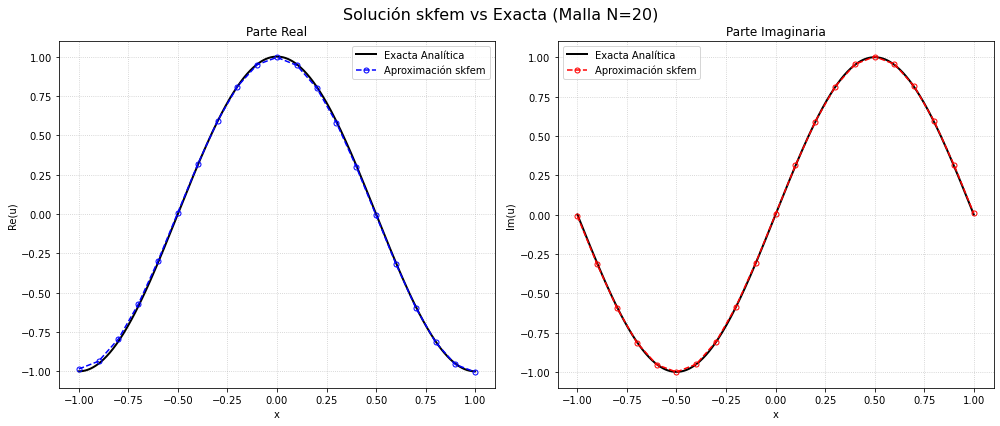

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfem as skf
from skfem.helpers import dot, grad

# Asegúrate de tener la librería instalada: 
# pip install scikit-fem pandas matplotlib

# ---------------------------------------------------------
# 1. Definición de Parámetros y Solución Manufacturada
# ---------------------------------------------------------
k = 2.0
sigma1 = 1.0j
sigma2 = 1.0j

def u_exacta(x):
    return np.exp(1j * np.pi * x)

def fuente_f(x):
    return (np.pi**2 - k**2) * np.exp(1j * np.pi * x)

g1 = 1j * (np.pi - 1.0)
g2 = -1j * (np.pi + 1.0)

# ---------------------------------------------------------
# 2. Formas Débiles con scikit-fem
# ---------------------------------------------------------
# Términos del dominio interior (Integral principal)
@skf.BilinearForm(dtype=complex)
def a(u, v, w):
    return dot(grad(u), grad(v)) - (k**2) * u * v

@skf.LinearForm(dtype=complex)
def l(v, w):
    return fuente_f(w.x[0]) * v

# Términos de la frontera de Robin (Facetas)
@skf.BilinearForm(dtype=complex)
def robin_lhs(u, v, w):
    # w.x[0] contiene la coordenada x. Diferenciamos izquierda de derecha.
    sigma = np.where(w.x[0] < 0, sigma1, sigma2)
    return sigma * u * v

@skf.LinearForm(dtype=complex)
def robin_rhs(v, w):
    g = np.where(w.x[0] < 0, g1, g2)
    return g * v

# ---------------------------------------------------------
# 3. Test de Convergencia
# ---------------------------------------------------------
N_values = [10, 20, 40, 80, 160, 320, 640]
resultados = []

N_plot = 20
x_plot, u_num_plot, u_ex_plot, x_ex_plot = None, None, None, None

for i, N in enumerate(N_values):
    # Malla 1D y Elemento Finito Lineal (P1)
    m = skf.MeshLine(np.linspace(-1.0, 1.0, N+1))
    e = skf.ElementLineP1()
    
    # Bases espaciales
    basis = skf.Basis(m, e)               # Base para el volumen
    fbasis = skf.FacetBasis(m, e)         # Base para la frontera por defecto
    
    # Ensamblaje iterativo simplificado por skfem
    A = skf.asm(a, basis) + skf.asm(robin_lhs, fbasis)
    b = skf.asm(l, basis) + skf.asm(robin_rhs, fbasis)
    
    # Resolución del sistema complejo
    u_num = skf.solve(A, b)
    
    # Extracción de coordenadas y evaluación de errores
    x_num = m.p[0]  # Coordenadas de los nodos
    h = x_num[1] - x_num[0]
    u_ex = u_exacta(x_num)
    
    error_L2 = np.sqrt(np.sum(np.abs(u_num - u_ex)**2) * h)
    error_Linf = np.max(np.abs(u_num - u_ex))
    
    orden_L2 = np.nan
    orden_Linf = np.nan
    
    if i > 0:
        h_prev = resultados[-1]['h']
        eL2_prev = resultados[-1]['Error L2']
        eLinf_prev = resultados[-1]['Error Linf']
        
        orden_L2 = np.log(eL2_prev / error_L2) / np.log(h_prev / h)
        orden_Linf = np.log(eLinf_prev / error_Linf) / np.log(h_prev / h)
        
    resultados.append({
        'N': N,
        'h': h,
        'Error L2': error_L2,
        'Orden L2': orden_L2,
        'Error Linf': error_Linf,
        'Orden Linf': orden_Linf
    })
    
    if N == N_plot:
        x_plot = x_num
        u_num_plot = u_num
        x_ex_plot = np.linspace(-1.0, 1.0, 500)
        u_ex_plot = u_exacta(x_ex_plot)

# ---------------------------------------------------------
# 4. Resultados y Gráficas
# ---------------------------------------------------------
df_convergencia = pd.DataFrame(resultados)
pd.options.display.float_format = '{:.4e}'.format
print("\n--- Tabla de Convergencia (Usando scikit-fem) ---")
print(df_convergencia.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Solución skfem vs Exacta (Malla N={N_plot})', fontsize=16)

ax1.plot(x_ex_plot, u_ex_plot.real, 'k-', linewidth=2, label='Exacta Analítica')
ax1.plot(x_plot, u_num_plot.real, 'bo--', markersize=5, mfc='none', label='Aproximación skfem')
ax1.set_title('Parte Real')
ax1.set_xlabel('x')
ax1.set_ylabel('Re(u)')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

ax2.plot(x_ex_plot, u_ex_plot.imag, 'k-', linewidth=2, label='Exacta Analítica')
ax2.plot(x_plot, u_num_plot.imag, 'ro--', markersize=5, mfc='none', label='Aproximación skfem')
ax2.set_title('Parte Imaginaria')
ax2.set_xlabel('x')
ax2.set_ylabel('Im(u)')
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

=== EJEMPLO 1: Análisis de Convergencia FOSLS ===
N =  32 | Error L2 = 6.1795e-01 | Orden = N/A

=== EJEMPLO 2: Pulso Atenuado ===


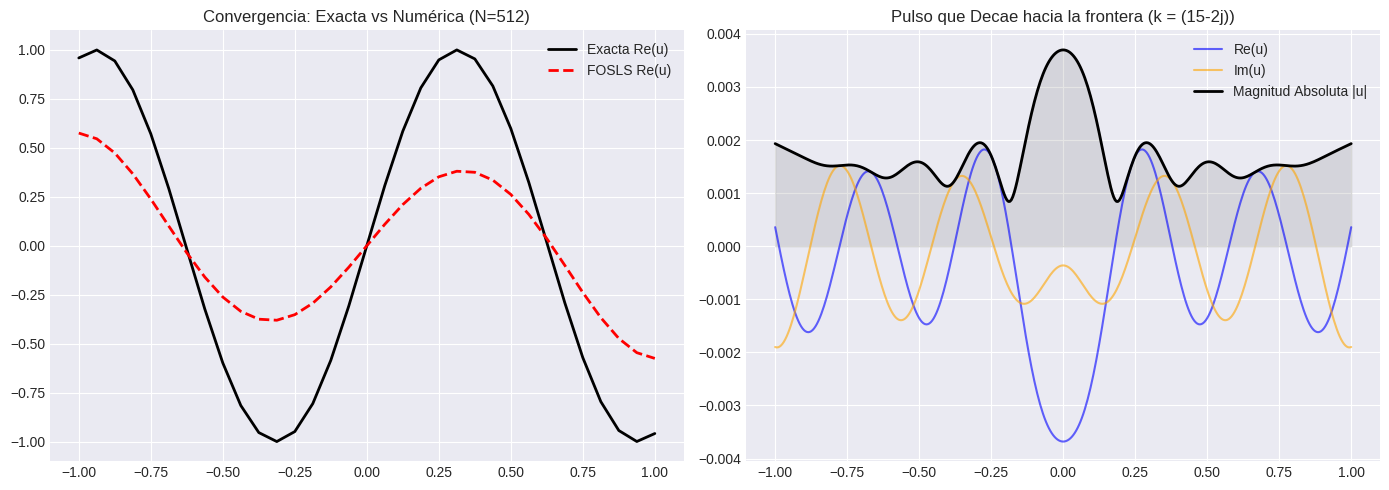

In [6]:
%matplotlib inline
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

# Configuración visual para los gráficos en el Notebook
plt.style.use('seaborn-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

def resolve_fosls_helmholtz(N, k, f_func, g1, g2):
    """
    Resuelve la ec. de Helmholtz 1D mediante FOSLS y elementos P1.
    N: Número de elementos
    k: Número de onda
    f_func: Función fuente f(x)
    g1, g2: Condiciones de contorno de tipo radiación
    """
    x = np.linspace(-1, 1, N+1)
    h = x[1] - x[0]
    
    # 2 grados de libertad por nodo (U y V)
    ndof = 2 * (N + 1)
    K = sp.lil_matrix((ndof, ndof), dtype=complex)
    F = np.zeros(ndof, dtype=complex)
    
    # Puntos y pesos de Cuadratura de Gauss (2 puntos en [0, 1])
    xi_q = np.array([0.5 - np.sqrt(3)/6, 0.5 + np.sqrt(3)/6])
    w_q = np.array([0.5, 0.5])
    
    # Matrices base locales pre-calculadas analíticamente
    M_loc = (h/6) * np.array([[2, 1], [1, 2]], dtype=complex)  
    S_loc = (1/h) * np.array([[1, -1], [-1, 1]], dtype=complex) 
    M_BN = np.array([[-0.5, -0.5], [0.5, 0.5]], dtype=complex)  
    M_NB = np.array([[-0.5, 0.5], [-0.5, 0.5]], dtype=complex)  
    
    # Bloques locales FOSLS
    K_UU = S_loc + (k**4) * M_loc
    K_VV = S_loc + M_loc
    K_UV = -M_BN + (k**2) * M_NB
    K_VU = K_UV.T
    
    # Ensamblaje Global
    for i in range(N):
        idx_U = [2*i, 2*i+2]
        idx_V = [2*i+1, 2*i+3]
        
        # Ensamblaje de matriz de rigidez
        for a in range(2):
            for b in range(2):
                K[idx_U[a], idx_U[b]] += K_UU[a, b]
                K[idx_U[a], idx_V[b]] += K_UV[a, b]
                K[idx_V[a], idx_U[b]] += K_VU[a, b]
                K[idx_V[a], idx_V[b]] += K_VV[a, b]
                
        # Ensamblaje del vector de carga (integración numérica)
        for q, w in zip(xi_q, w_q):
            xq = x[i] + h * q
            fq = f_func(xq)
            Nq = np.array([1-q, q])
            Bq = np.array([-1/h, 1/h])
            
            # F_U = \int -f * (k^2 * N) dx
            F[idx_U[0]] += -fq * (k**2) * Nq[0] * h * w
            F[idx_U[1]] += -fq * (k**2) * Nq[1] * h * w
            # F_V = \int -f * B dx
            F[idx_V[0]] += -fq * Bq[0] * h * w
            F[idx_V[1]] += -fq * Bq[1] * h * w

    # --- Condiciones de Frontera Penalizadas (Nodos extremos) ---
    # Frontera Izquierda (x = -1) -> Nodo 0 (U: 0, V: 1)
    K[0, 0] += k**2
    K[0, 1] += -1j * k
    K[1, 0] += 1j * k
    K[1, 1] += 1.0
    F[0] += 1j * k * g1
    F[1] += -g1

    # Frontera Derecha (x = 1) -> Nodo N (U: 2N, V: 2N+1)
    K[2*N, 2*N]     += k**2
    K[2*N, 2*N+1]   += 1j * k
    K[2*N+1, 2*N]   += -1j * k
    K[2*N+1, 2*N+1] += 1.0
    F[2*N]   += 1j * k * g2
    F[2*N+1] += g2

    # Resolver el sistema
    sol = spla.spsolve(K.tocsc(), F)
    u_sol = sol[0::2]
    v_sol = sol[1::2]
    
    return x, u_sol, v_sol


# ==========================================
# EJECUCIÓN Y GRÁFICOS (Se renderizará debajo de la celda)
# ==========================================

fig, axs = plt.subplots(1, 2)

# --- EJEMPLO 1: Análisis de Convergencia ---
print("=== EJEMPLO 1: Análisis de Convergencia FOSLS ===")
k_ex = 5.0
f_ex = lambda x: 0.0 * x  # Helmholtz homogéneo

# Solución analítica de prueba: u(x) = sin(k*x), v(x) = k*cos(k*x)
u_exacta = lambda x: np.sin(k_ex * x)
v_exacta = lambda x: k_ex * np.cos(k_ex * x)

g1_ex = -v_exacta(-1) - 1j*k_ex*u_exacta(-1)
g2_ex = v_exacta(1) - 1j*k_ex*u_exacta(1)

tamanos_malla = [32]#, 64, 128, 256, 512]
errores = []

for N_iter in tamanos_malla:
    x_num, u_num, _ = resolve_fosls_helmholtz(N_iter, k_ex, f_ex, g1_ex, g2_ex)
    error_L2 = np.sqrt(np.sum(np.abs(u_num - u_exacta(x_num))**2) * (2.0/N_iter))
    errores.append(error_L2)
    if len(errores) == 1:
        print(f"N = {N_iter:3d} | Error L2 = {error_L2:.4e} | Orden = N/A")
    else:
        orden = np.log2(errores[-2]/errores[-1])
        print(f"N = {N_iter:3d} | Error L2 = {error_L2:.4e} | Orden = {orden:.2f}")

axs[0].plot(x_num, u_exacta(x_num).real, 'k-', lw=2, label='Exacta Re(u)')
axs[0].plot(x_num, u_num.real, 'r--', lw=2, label='FOSLS Re(u)')
axs[0].set_title('Convergencia: Exacta vs Numérica (N=512)')
axs[0].legend()

# --- EJEMPLO 2: Pulso con Decaimiento en Frontera ---
print("\n=== EJEMPLO 2: Pulso Atenuado ===")
N_pulso = 400
# k con una parte imaginaria negativa para medio atenuante (lossy medium)
k_lossy = 15.0 - 2.0j 
# Pulso gaussiano concentrado en el centro
f_pulso = lambda x: np.exp(-150 * x**2)
# Condiciones de frontera de radiación libres
g1_p, g2_p = 0.0, 0.0 

x_p, u_p, v_p = resolve_fosls_helmholtz(N_pulso, k_lossy, f_pulso, g1_p, g2_p)

axs[1].plot(x_p, u_p.real, color='blue', alpha=0.6, label='Re(u)')
axs[1].plot(x_p, u_p.imag, color='orange', alpha=0.6, label='Im(u)')
axs[1].plot(x_p, np.abs(u_p), color='black', lw=2, label='Magnitud Absoluta |u|')
axs[1].fill_between(x_p, np.abs(u_p), color='gray', alpha=0.2)
axs[1].set_title(f'Pulso que Decae hacia la frontera (k = {k_lossy})')
axs[1].legend()

plt.tight_layout()
plt.show()